In [1]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용

/content/drive/MyDrive/Colab Notebooks/딥러닝/LLM 활용


- 의존성 라이브러리 설치

In [3]:
!pip install -qU langchain langchain-core langchain-community langchain-openai
!pip install -qU langgraph
# ERROR
# colab에서 사용하는 requests 버전이 langchain의 의존성 버전보다 높아요!
# -> 경고가 나와도 크게 문제가 없음 -> 진행해도 됨

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.1/113.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.8/173.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


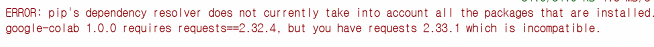


- API 키 등록

In [ ]:
api_key = "본인의 OpenAI API 키를 입력하세요"

# 환경 변수 등록
import os

# 키값 추가
os.environ['OPENAI_API_KEY'] = api_key

# Single Agent
- 지금까지 사용한 구조
- 하나의 LLM 에이전트가 모든 요청을 처리

In [5]:
# 필요한 라이브러리 불러오기

# LLM 초기화 함수 (모델의 객체 생성)
from langchain.chat_models import init_chat_model

# 일반 파이썬 함수를 Langchain 'Tool' 객체로 변환시켜주는 데코레이터
# 에이전트가 해당 함수를 도구로 인식하고 필요 할 때 불러다 쓸 수 있다.
from langchain_core.tools import tool

# LangGraph 기반 ReAct 에이전트 그래프를 만들어 주는 기능
from langchain.agents import create_agent

# 타입 힌트용 유틸(특정 문자열 값만 허용하도록 타입을 제한 할때 사용)
# 예 : Literal['서울', '광주'] -> 인자로 받을 수 있는 값이 '서울' / '광주'
from typing import Literal

In [6]:
# 모델 초기화
llm = init_chat_model(
    model = 'openai:gpt-4.1', # 사용할 거대 언어모델 이름
    temperature = 0,          # 생성되는 답변의 창의성을 조절 (0으로 준 경우 결정론적인 응답)
    max_tokens = 500,         # 응답 생성시 몇개의 토큰까지 사용 할 수 있는지
#    스트리밍 기능은 주석으로 비활성화
#    streaming = True,        # 스트리밍 모드 활성화
#    callbacks = [StreamingStdOutCallbackHandler()] # 스트리밍 응답을 콘솔에 출력하는 핸들러 설정
)

- 단일 에이전트에서 사용할 간단한 Tool 정의

In [7]:
# 날씨 관련된 내용으로 간단한 Tool을 정의 해보자.
# 수업용 예제로 도시이름에 따라 미리 정해둔 문장을 반환

@tool
def get_weather(city : Literal['서울', '광주']) -> str :
  '''
  단순한 날씨 조회 도구
  @tool 데코레이터 덕분에 이 함수는 Langchain으로 만들어진 에이전트가 호출하는 도구가 되었다.
  - 입력 인자 타입 : city :
    - Literal['서울', '광주'] -> 타입 제한이 걸린 상태
    - 서울과 광주를 제외하고 다른값은 사용하지 않겠다. 정의해줌
    --> str : 이 함수는 문자열을 반환한다,
  '''
  if city == '서울' :
    return '서울은 오늘 흐리고 후덥지근 합니다.'
  elif city == '광주' :
    return '광주는 오늘 흐리고 바람이 많이 붑니다'
  else :
    # Literal Type 으로 입력값을 제한 해 뒀지만
    # 혹시라도 다른값이 들어왔을떼 방어하기 위한 예외 처리
    raise ValueError('지원하지 않는 도시입니다.')

- 단일 ReAct 에이전트 구현
- `create_agent` : LangGraph 기반 ReAct 에이전트 그래프 생성

In [8]:
# 1) 사용할 툴 리스트
tools = [get_weather]

In [9]:
# 2) 단일 ReAct 에이전트 그래프 생성 (Single Agent)
single_agent = create_agent(
    model = llm, # 에이전트가 의사결정 할 때 어떤 모델을 사용할 것인가?
                 # - 어떤 툴을 쓸지 / 어느 시점에서 도구를 쓸지 / 최종 답변 제시 등 판단하는 모델
    tools = tools,# 위에서 정의한 도구 리스트
                  # - 에이전트는 이 리스트를 보고 도구목록을 인지

    system_prompt=(
        # 시스템 프롬프트 :
        # - 에이전트의 역할 / 톤 / 규칙 등을 사전에 정의하는 문장
        # - 매번 대화 시작전에 LLM에 주입되는 고정 명령어 (컨텍스트)
        '당신은 한국 주요 도시의 날씨를 알려주는 친절한 AI 비서입니다.'
        '모르는 정보는 지어내지 말고 툴에서 제공된 정보만 바탕으로 답변해주세요'
    )
)

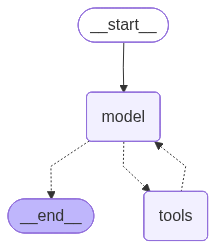

In [ ]:
single_agent
# 흐름도 보여준다

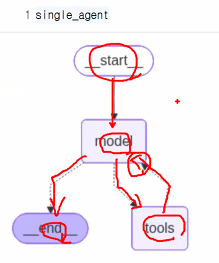

In [10]:
single_agent.stream(...)

<generator object Pregel.stream at 0x12e2cf10>

- Single Agent 실행 + 스트리밍 출력 헬퍼 함수
- `create_agent()`가 반환하는 에이전트는 LangGraph "그래프"이기 때문에 `.invoke()`, `.stream()` 둘 다 가능

In [11]:
def print_stream(stream) :
  '''
  graph.stream(...)의 결과를 받아서
  매 단계에서 마지막 메세지만 깔끔하게 출력해주는 헬퍼 함수

  stream 인자 :
  - single_agent.stream(...)이 반환하는 제너레이터(값을 하나씩 순서대로 반환하는 객체)
  - 내부적으로는 LangGrpah의 State(dict)가 반복해서 넘어옴
  예 : {"message" : [SystemMessage, HumanMessage, AIMessage...]}

  동작 방식 :
  1. for문으로 각 state를 순회
  2. state["message"]에서 마지막 메세지를 꺼내옴
  3. pretty_print()함수로 콘솔에서 보기 좋은 형태로 출력
  '''
  for state in stream :
    # state는 LangGraph에 상태 딕셔너리
    # message = state['message'][-1] : 최종 마지막 대답을 불러오겠다
    message = state['messages'][-1]
    # LangChain의 표준 메세지 타입은 pretty_print()을 통해 문장을 정리해서 반환 할 수 있다.
    message.pretty_print()

- 단일 턴 예시 실행

In [12]:
# 사용자 입력을 LangChain / LangGraph에서 요구하는 형태로 감싸기
# - "messages"키 아래 (role, content) 튜플 리스트를 넣는 방식
# - 실제로는 HumanMessage 등의 객체를 사용 / 간단한 예제에서는 튜플 형식도 지원
inputs = {
    'messages' : [
        ('user', '서울 날씨 어때?') # 사용자의 역할과 실제 질문 내용
    ]
}

In [13]:
# 에이전트 불러와서 답변을 확인해보자
print_stream(
    single_agent.stream(  # 그래프가 생각 -> 도구 부르기 -> 관찰 -> 답변 과정을 진행하도록 만듬
                          # 중간마다 state를 스트리밍 방식으로 넘겨줌
        inputs,
        stream_mode = 'values'  # 이벤트 단위가 아니라 state(dict)만 연속적으로 받겠다.
                                # state['messages']만 쓰기 때문에 values 모드가 간단함
    )
)

================================ Human Message =================================

서울 날씨 어때?
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_E9zusKqnpxcWCbP68jHbXp7t)
 Call ID: call_E9zusKqnpxcWCbP68jHbXp7t
  Args:
    city: 서울
================================= Tool Message =================================
Name: get_weather

서울은 오늘 흐리고 후덥지근 합니다.
================================== Ai Message ==================================

서울은 오늘 흐리고 후덥지근한 날씨입니다. 외출 시 참고하세요!


> 예를 들어, 단일 에이전트 + get_weather 하나인 상태에서는
> ```
> “서울 날씨 어때?”
> “부산은 어때?”
> ```
> 같은 요청은 깔끔하게 처리할 수 있음

- 하지만 <font color = "red">요구사항이 점점 늘어나면 문제</font>가 생김

> 예)
> “서울이랑 부산 날씨 비교해주고, 마지막에 영어로 한 문장 요약도 해줘.”

- 이걸 한 싱글 에이전트에 모든 툴을 몰아넣어서 처리하려고 하면
    1. <b>Tool 과다(Too many tools)</b>
        - 날씨 조회, 번역, 검색, DB 조회, 캘린더, 메일 발송…
        - <font color = "red">하나의 에이전트에 툴을 계속 추가</font>하다 보면 → LLM 입장에서는 “어떤 도구를 언제 써야 하는지” <font color = "red">판단이 점점 어려워짐</font>

    2. <b>컨텍스트(메시지 히스토리) 과부하</b>
        - 한 에이전트가 전체 대화 히스토리 모든 툴 호출 결과 요약/메모리까지 전부 다 안고 가야 할 수도 있음
        - 컨텍스트 길이가 길어질수록 <font color = "red">비용·속도 문제 발생</font>하면서, <font color = "red">중요한 정보만 골라 쓰기 어려움</font>
    
    3. <b>전문화 부족</b>
        - 기획자/리서처/번역가/수학전문가/개발자…
        - 각 역할에 요구되는 “톤 & 스킬”이 다름
        - <font color = "red">한 에이전트에게 모든 역할을 맡기면</font> → <font color = "red">답변이 애매</font>하게 섞이거나, 특정 영역에서만 잘하는 기형적인 결과가 나올 수 있음

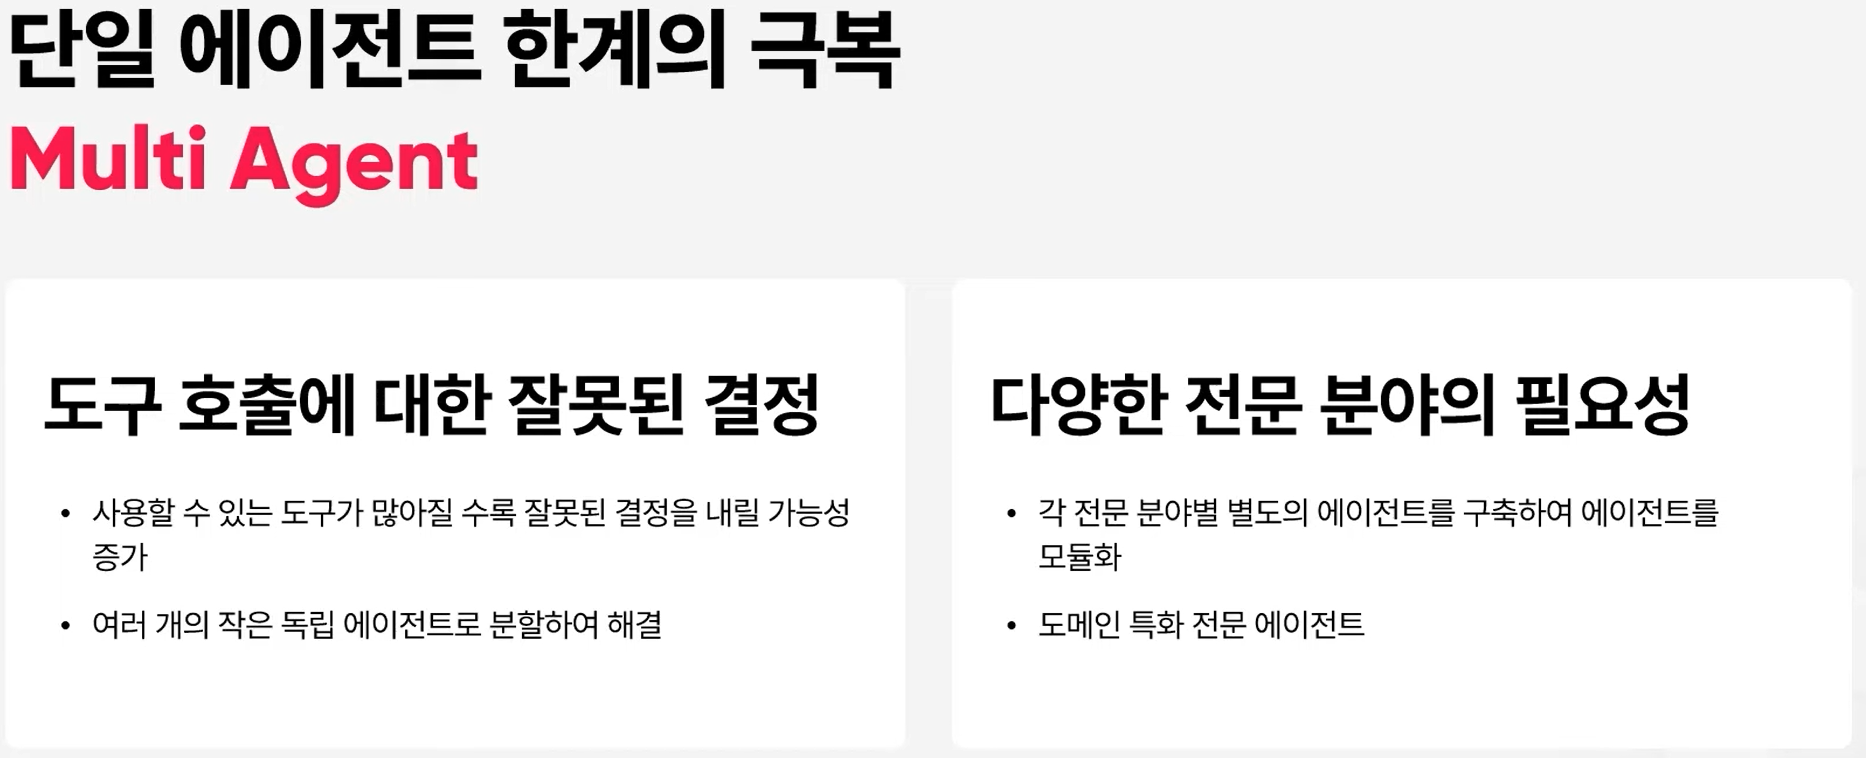

# Agent Architecture (에이전트 아키텍처)
- 보다 복잡한 워크플로우를 구성하기 위해 여러 가지 **에이전트 아키텍처**를 조합해서 사용

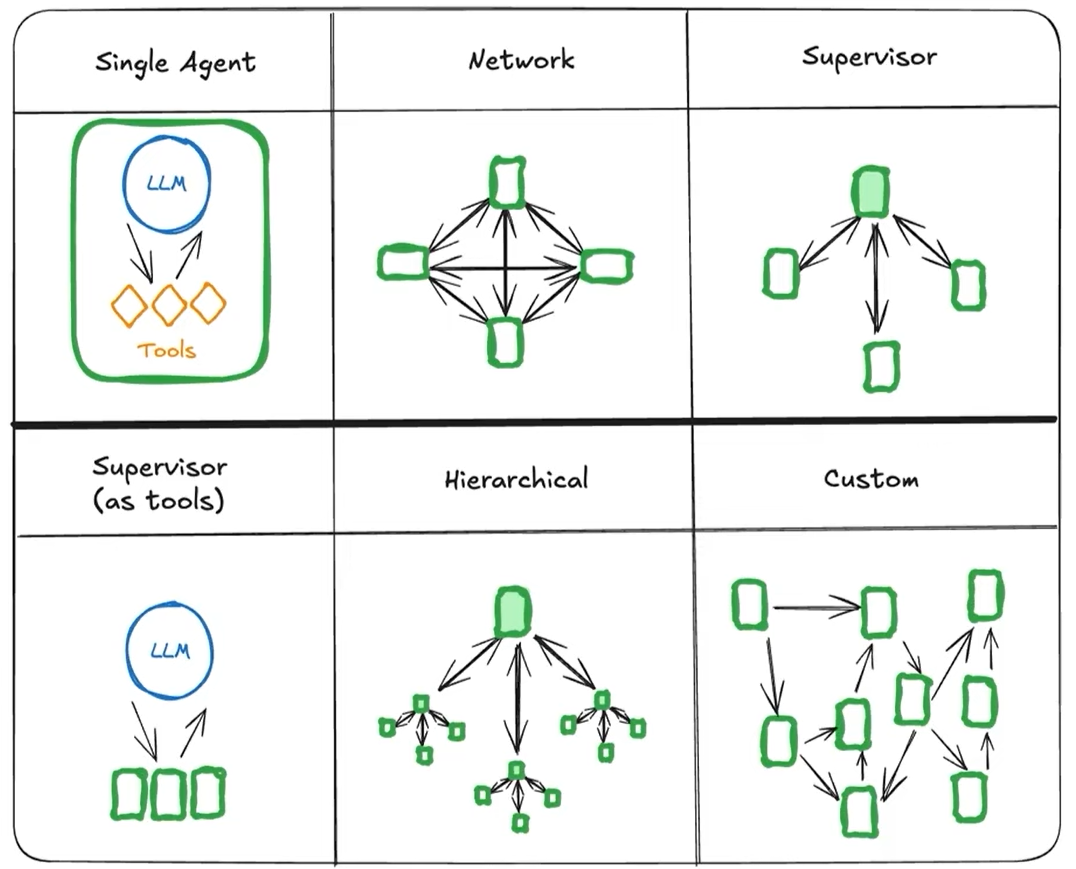

## Single Agent
- 지금까지 만든 `agent`에 대한 구조

> 하나의 에이전트가 `모델 호출`, `도구 호출`, `답변 생성` 등 모두 담당
> - 구조는 단순하지만, 도메인과 툴이 늘어날수록 관리가 어려워짐

## Network 구조

- **여러 에이전트들이 서로 연결된 상태**를 그래프처럼 구성
- 명확한 상하 관계가 없는 “에이전트 네트워크”

> 각 에이전트는 하나의 노드(node)로 표현되고, 에이전트 간 이동 (어느 에이전트가 다음으로 동작할지)은
> - 룰 기반(if/else)
> - 또는 LLM이 결정(conditional edge)

## Supervisor 구조

- **중앙의 Supervisor(감독자) 에이전트**가 존재

> 실제 작업은 여러 Worker 에이전트들이 담당
> - 예: `Researcher`, `MathExpert`, `Writer` 등

- Supervisor는 현재 상태를 보고 `어느 에이전트를 호출할지`, `언제 종료할지` 를 결정

## Supervisor(as Tools) 구조

- Supervisor가 **다른 에이전트들을 "툴"처럼 사용**하는 패턴

- 즉, Sub-Agent를 LangGraph/LangChain에서 **Tool로 래핑**해서
  - `controller_agent` → `subagent1_tool` 호출
  - `controller_agent` → `subagent2_tool` 호출
  식으로 구현
- “에이전트를 툴처럼 감싼다”는 점이 특징

## Hierarchical 구조

- Supervisor가 한 명이 아니라 `상위 Supervisor`, `하위 팀 Supervisor`, `그 아래 Worker 에이전트들…` 로 **계층 구조**를 이루는 패턴

> 예:
> - 최상위 Supervisor: “보험 상담 시스템 전체 책임”
> - 중간 Supervisor: “청구 처리 팀”, “상품 추천 팀”
> - 하위 에이전트: 실제 검색/분석/요약 담당

## Custom 구조

- 위 구조들을 섞어서 **서비스에 맞는 맞춤형 그래프**를 만드는 형태
- 규칙이 보이지 않음

> 예:
> - 상위 Supervisor + 하위 Network
> - Network 내부에서 Handoffs 활용
> - 특정 단계만 별도의 Subgraph로 분리 등

# 멀티 에이전트 – Supervisor 구조
> 단일 에이전트로 모든 툴과 도메인을 처리하는 대신, <br>
> 여러 개의 전문 에이전트(Worker) 를 두고 Supervisor(감독자) 가 <br>
> 이들을 조율하는 구조 → Supervisor 패턴

- LangGraph 공식 docs에서도 추천되는 대표 패턴

#### Single LLM Agnet

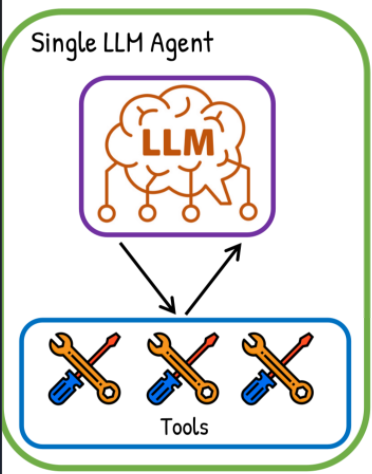


#### Multi Agent LLM System

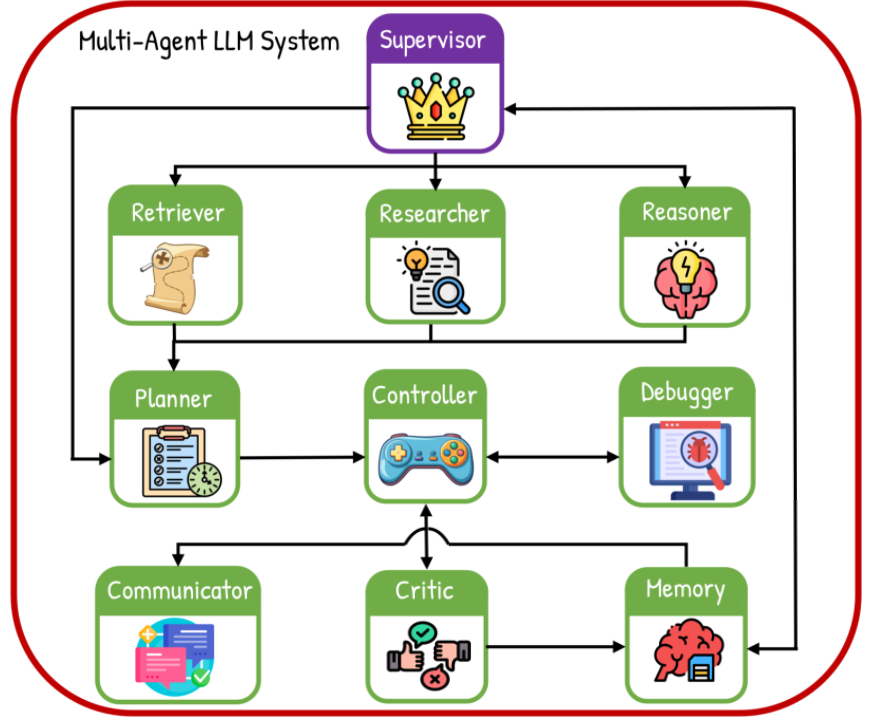

## 부모 그래프와 서브 그래프

#### 부모 그래프(Parent Graph)
- 전체 워크플로우를 관리하는 상위 그래프
- 여러 에이전트 또는 서브그래프들을 조합하여 하나의 큰 프로세스를 구성
- 전체 실행 순서와 흐름을 조율하는 “메인 컨트롤러” 역할
- 다양한 서브그래프를 호출하고, 그 결과를 통합하여 최종 응답 생성
- ex. `Entry Graph`

> 역할
> - 사용자 로그(logs)를 받아 처리 시작
> - 필요한 서브그래프를 호출 (예: Summarization, Failure Analysis)
> - 서브그래프 실행 결과를 통합해 최종 보고서 생성(summary report / failure report)
> - 전체 업무 플로우를 하나의 시스템으로 연결하는 “오케스트레이터”

---

#### 서브 그래프(Subgraph)
- 특정 역할을 수행하도록 설계된 작은 그래프
- ex. `Summarization(요약)`, `Failure Analysis(실패 분석)`
- 그 밖에도 번역, 문서 요약(summarization), RAG 검색, 오류 분석(failure analysis) 등 다양한 Task로 만들 수 있음

> 역할
> - 하나의 독립적인 컴포넌트처럼 동작 → Parent Graph에서 노드처럼 재사용 가능
> - 입력 상태(state)를 받아 내부에서 자체적인 처리 후 새로운 state 생성
> - 처리된 결과(summary report, failure report 등)를 parent에게 돌려줌

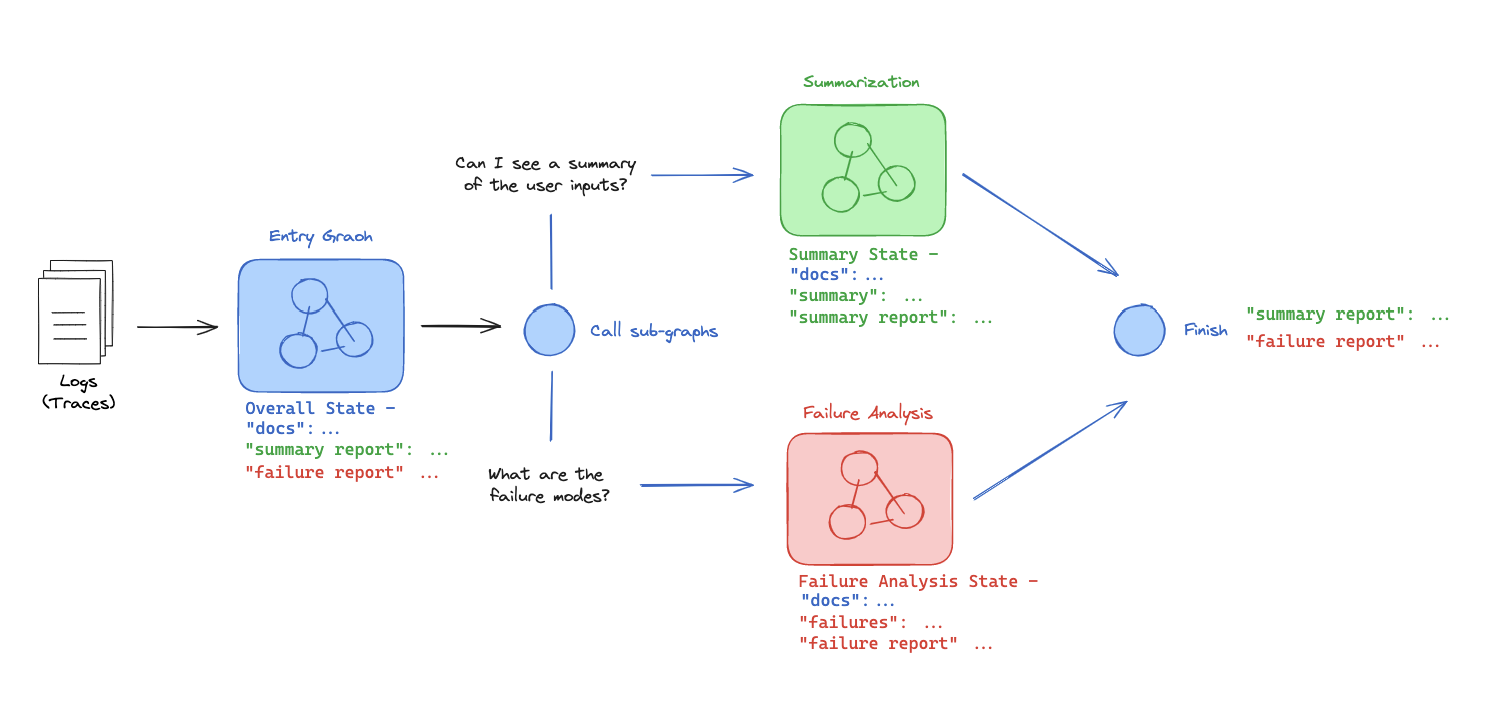

##### 🔁 흐름 예시

① Logs(입력 데이터) → Entry Graph(부모 그래프)
- 부모 그래프는 전체 처리의 시작점이며, 입력 데이터를 받아 초기 state를 설정
<br>

② Parent Graph → 서브그래프 호출 (Call subgraphs)
- 부모 그래프는 특정 요청/조건에 따라 **서브그래프를 호출**함
<br>

> 예시: <br>
> 사용자 문서를 요약해줘” → Summarization Subgraph 호출 <br>
> “이 문서에서 실패 원인을 분석해줘” → Failure Analysis Subgraph 호출

- 서브그래프는 부모 그래프의 일부처럼 작동하지만 **독립적인 처리 흐름**을 가짐
<br>

③ Subgraph → 결과 생성 후 Parent Graph로 복귀

> 서브그래프는 다음과 같은 state를 반환
> - Summarization Subgraph
>    - `"summary": ...`
>    - `"summary report": ...`
> - Failure Analysis Subgraph
>    - `"failures": ...`
>    - `"failure report": ...` <br>
>
> 이 값들이 통합되어 Parent Graph의 전체 state에 반영

<br>

④ Parent Graph → Finish(최종 결과)
- 부모 그래프는 모든 서브그래프의 결과를 합쳐 최종 결과를 만듬

> 이미지에서는 최종 state에 다음이 포함됨
> - `"summary report": ...`
> - `"failure report": ...`

# Multi Agent - Supervisor Agent 구현해보기

```
Supervisor Agent
   ├── Weather Agent (날씨 조회 전문가) → Tool 호출
   ├── Translator Agent (번역 전문가)
   └── Summary Agent (요약 전문가)
```

> Supervisor는 “사용자 요청을 해석 → 어떤 Worker 에이전트를 호출할지 결정 → 결과를 합쳐 최종 응답 생성”.

## LLM 없이, if/else 로 <b>plan 문자열</b> 만들어 보기

`LangGraph 적용 전 확인 실습`

- 멀티 에이전트의 핵심은 <font color = "red">어떤 작업 순서로 처리할지 계획(plan)을 정하는 것</font>
- 로우레벨 파이썬 함수로 구현 연습

> LangChain / LangGraph 공식 문서의 multi-agent 예제에서는 "라우터(router) 역할"이 필요함 <br>
> LLM 없이, 규칙 기반(if/else)으로만 계획(plan)을 세우는 연습 단계 <br>
> 나중에 LangGraph + 에이전트로 확장될 때, 이 함수가 Supervisor의 의사결정 기준(plan)이 되는 구조라고 보면 됨

In [14]:
def extract_plan(user_text: str) -> str:
    """
    사용자 질문(문장)을 읽고, 이 요청을 어떤 ‘작업 단계(plan)’로 처리할지 결정하는 함수 정의
    --------------------------------------------------------------------------------------
    📌 어떤 함수인가?
       - 사용자 자연어 입력을 보고 "날씨만 필요한가?", "번역만 필요한가?",
         "둘 다 필요한가?" 같은 작업 계획을 자동으로 분류함
       - Supervisor가 어떤 Worker Agent를 호출할지 결정하기 위한 '지시서'를 만드는 역할

    📌 인자값 설명
       - user_text : 사용자가 입력한 자연어 문장 (예: "서울 날씨 알려주고 영어로 한 문장 말해줘")

    📌 동작 요약
       1) 도시 키워드(서울·부산) 등장 여부 검사 → 날씨 조회 필요성 판단
       2) 번역 관련 키워드(영어·번역·영문) 등장 여부 검사 → 번역 필요성 판단
       3) 두 조건 조합에 따라 4가지 plan 문자열 중 하나 반환

    반환되는 plan 종류
       - "weather_then_translate" : 날씨 조회 + 번역 둘 다 필요
       - "weather_only"           : 날씨만 필요
       - "translate_only"         : 번역만 필요
       - "finish"                 : 아무 작업도 필요 없음(바로 종료)
    --------------------------------------------------------------------------------------
    """

    # --------------------------------------------
    # 1) 도시 이름(서울, 부산)이 문장에 포함되어 있는지 검사
    #    - any(조건 for 요소 in 리스트):
    #        → 리스트 안에 하나라도 True가 있으면 True 반환
    #    - 여기서는 user_text 안에 "서울" 또는 "부산"이 들어 있는지 검사
    # --------------------------------------------
    has_city = any(city in user_text for city in ["서울", "부산"]) # "서울이나 부산 이야기가 있나?" (날씨 조회가 필요한지 확인)

    # --------------------------------------------
    # 2) 번역 관련 키워드가 포함되어 있는지 검사
    #    - "영어", "번역", "영문" 중 하나라도 들어 있으면
    #      "번역 작업이 필요하다"고 판단
    #    - 실제 multi-agent 예제에서의 "intent 분류"에 해당하는 역할을
    #      지금은 키워드 기반으로 단순화해서 구현한 것
    # --------------------------------------------
    need_translate = any(k in user_text for k in ["영어", "번역", "영문"]) # "영어라든가 번역이라는 말이 있나?" (번역 기능이 필요한지 확인)

    # --------------------------------------------
    # 3) 조건 조합에 따라 plan 문자열 결정
    #    - has_city, need_translate 두 개의 불리언 값 조합으로
    #      4가지 케이스를 나눔
    #    - 이 plan 문자열이 나중에 Supervisor / LangGraph에서
    #      "어떤 에이전트를 어떤 순서로 실행할지"를 결정하는 기준이 됨
    # --------------------------------------------

    # (1) 도시도 있고, 번역 키워드도 있는 경우 → 날씨 + 번역 둘 다 필요
    if has_city and need_translate:
        return "weather_then_translate"   # 날씨 → 번역 순서로 처리할 계획

    # (2) 도시만 있고, 번역 키워드는 없는 경우 → 날씨만 필요
    if has_city and not need_translate:
        return "weather_only"             # 날씨만 처리하는 계획

    # (3) 도시는 없고, 번역 키워드는 있는 경우 → 번역만 필요
    if (not has_city) and need_translate:
        return "translate_only"           # 번역만 처리하는 계획

    # (4) 그 외: 도시도 없고, 번역 키워드도 없음 → 특별히 할 작업 없음
    #     → Supervisor 입장에서는 바로 종료하는 플랜
    return "finish"

In [15]:
# 위에서 만든 extract_plan 동작 확인하기
test = [
    '서울 날씨 알려줘',
    '서울 날씨 알려주고 영어로 번역해줘',
    '다음 문장을 영어 한 문장으로 번역해주세요 : 안녕하세요',
    '그냥 잡담이야.'
]

for t in test :
  print(t, '->', extract_plan(t))

서울 날씨 알려줘 -> weather_only
서울 날씨 알려주고 영어로 번역해줘 -> weather_then_translate
다음 문장을 영어 한 문장으로 번역해주세요 : 안녕하세요 -> translate_only
그냥 잡담이야. -> finish


### 20260504

## LLM 없이, <b>Supervisor 미니 버전</b> 만들어보기

`LangGraph 적용 전 확인 실습`

- 위에서 만든 plan 문자열(what to do)을 바탕으로, <b>현재 step 에서 어떤 일을 해야 할지</b>를 결정하는 결정하는 미니 Supervisor 구현해보기
-  함수 인자/반환값만으로 Supervisor의 의사결정 구조를 딕셔너리로만 구현 연습

> 이후에 LangGraph StateGraph에 들어가면
> - plan, step은 state 안에 들어가고
> - simple_supervisor가 결정한 값은 state["route"]에 저장되어
> - add_conditional_edges(...)에서 다음 노드(Worker)를 고르는 데 쓰이게 됨

In [18]:
def simple_supervisor(plan: str, step: int) -> str :
  """
    plan + step 조합을 보고,
    다음에 실행해야 하는 작업을 문자열로 반환하는 '미니 Supervisor'.

    반환 문자열 (다음 Worker 혹은 종료 상태를 상징하는 심볼):
      - "WEATHER_AGENT"
      - "TRANSLATOR_AGENT"
      - "FINISH"

    📌 인자값 설명
      - plan : extract_plan()에서 만들어진 실행 계획 문자열
               ("weather_only", "translate_only", "weather_then_translate", "finish")
      - step : 현재 몇 번째 단계인지 나타내는 정수 (0, 1, 2, ...)

    📌 왜 이런 구조를 쓰는가?
      - LangChain docs의 multi-agent / handoffs 개념에서 말하는 것처럼,
        Supervisor는 직접 일을 하지 않고
        "어떤 Worker에게 제어권을 넘길지" 결정하는 역할만 담당.
      - 여기서는 아직 LangGraph Command, conditional_edges 등을 쓰지 않고,
        문자열만 반환해서 "라우팅 결과"를 표현하는 연습 단계.

    📌 실제 LangGraph와의 연결 포인트
      - 이 함수가 반환하는 문자열은 나중에
        state["route"]로 들어가고,
        add_conditional_edges("supervisor", lambda s: s["route"], {...})에서
        분기 키로 사용될 예정.
      - 즉, 지금 단계에서의 "WEATHER_AGENT / TRANSLATOR_AGENT / FINISH" 심볼은
        나중에 그래프 노드 이름과 1:1로 연결되는 설계라고 보면 됨.
  """
  # ============================================================
  # 1) plan == 'weather_only'인 경구
  # - 날씨 에이전트 한번만 실행하면 마무리
  # step 0 : WEATHER_AGENT 호출
  # step 1 : FINISH
  # ============================================================
  if plan == "weather_only":
      return "WEATHER_AGENT" if step == 0 else "FINISH"
  # ============================================================
  # 2) plan == 'translate_only'인 경구
  # - 번역 에이전트 한번만 실행하면 마무리
  # step 0 : TRANSLATOR_AGENT 호출
  # step 1 : FINISH
  # ============================================================
  elif plan == "translate_only":
      return "TRANSLATOR_AGENT" if step == 0 else "FINISH"
  # ============================================================
  # 3) plan == 'weather_then_translate'인 경구
  # step 0 : WEATHER_AGENT 호출 -> 날씨 제공 받음
  # step 1 : TRANSLATOR_AGENT 호출 -> 제공받은 날씨 번역
  # step 2 : FINISH
  # ============================================================
  elif plan == 'weather_then_translate':
    # 1번 순서 : 날씨 에이전트 실행
    if step == 0:
      return "WEATHER_AGENT"
    # 2번 순서 : 번역 에이전트 실행
    elif step == 1:
      return "TRANSLATOR_AGENT"
    # 3번 순서 : 모든 작업 마무리
    else :
      return 'FINISH'
  # ============================================================
  # 4) plan == 'finish'인 경우
  # step 0 : FINISH
  # 아무것도 하지 말고 바로 종료 해주세요
  # ============================================================

  return 'FINISH'

In [19]:
# simple_supervisor 가 의도한 대로 라우팅하는지 테스트
#   - 실제 LangGraph 조건부 edge에 연결하기 전에, 라우터(Supervisor)의 "상태 전이 규칙"을 눈으로 확인하는 단계

print(simple_supervisor("weather_only", 0))           # WEATHER_AGENT
print(simple_supervisor("weather_only", 1))           # FINISH

print(simple_supervisor("weather_then_translate", 0)) # WEATHER_AGENT
print(simple_supervisor("weather_then_translate", 1)) # TRANSLATOR_AGENT
print(simple_supervisor("weather_then_translate", 2)) # FINISH

WEATHER_AGENT
FINISH
WEATHER_AGENT
TRANSLATOR_AGENT
FINISH


## Handoffs (Supervisor가 Worker에게 제어권 넘기기)

`현재까지는 단순히 문자열("WEATHER_AGENT", "TRANSLATOR_AGENT", "FINISH")만 반환하지만, 개념적으로는 이미 "handoff"를 수행해봤음`

> Handoff이란?
> - 현재 Agent가 <b>이번 단계는 내가 아니라 다음 Agent가 처리해야 한다</b>고 판단하면, <b>제어권을 다른 노드(에이전트)</b>로 넘기는 것
> - Multi-Agent 구조에서 자주 나오는 패턴

1. step 0에서 "WEATHER_AGENT"를 반환한다 → 날씨 Worker에게 제어권 전달
2. 날씨 Worker 실행 후, step이 증가 → 다시 Supervisor 호출
3. Supervisor가 "TRANSLATOR_AGENT"를 반환 → 번역 Worker에게 제어권 전달
4. 마지막에 "FINISH"를 반환 → 더 이상 handoff 없이 종료

> 종류
> 1. 조건부 edge 방식
> 2. Command 기반 Handoff

### (1) 조건부 edge 방식
- if/else로 다음 노드 결정 ➜ 가장 직관적인 방식

In [24]:
from typing import Annotated, Sequence, TypedDict
# LangGraph State를 정의하기 위한 표준 라이브러리 타입
# Annotated : 특정 필드에 대한 '추가 정보'를 달아줄 때 사용
# TypedDict : dict 형태 데이터 구조를 타입으로 정의

from langgraph.graph import StateGraph, START, END, MessagesState
# StateGraph : LangGraph의 핵심 그래프 클래스
# -> 함수(노드) + 연결 규칙(엣지)을 정의해서 상태를 어떻게 흘려 보낼까 결정
# START, END : 그래프의 시작점 / 종료점을 나타내는 특수 노드 이름
# MessagesState : LangGraph에서 자주 사용하는 기본 상태 타입
# "Messages"라는 키에 메세지 리스트를 담는 구조를 제공

from langgraph.graph.message import add_messages
# LangGraph의 메세지 모듈에서 제공하는 유틸 함수
# Annotated 와 함께 사용되며 "기존 메세지에 새로운 메세지를 자동으로 이어붙이는 동작"을 정의

from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
# role(Human / AI / System)과 content(내용)을 함께 표현하는 클래스
# BaseMessage는 공통 부모 타입 -> Human / AI / Tool 등이 이를 상속해서 사용


In [25]:
# 모델 초기화
llm = init_chat_model(
    model = 'openai:gpt-4.1', # 사용할 거대 언어모델 이름
    temperature = 0,          # 생성되는 답변의 창의성을 조절 (0으로 준 경우 결정론적인 응답)
    max_tokens = 500,         # 응답 생성시 몇개의 토큰까지 사용 할 수 있는지
#    스트리밍 기능은 주석으로 비활성화
#    streaming = True,        # 스트리밍 모드 활성화
#    callbacks = [StreamingStdOutCallbackHandler()] # 스트리밍 응답을 콘솔에 출력하는 핸들러 설정
)

In [26]:
# Tool 정의 (위에서 구현한 get_weather 사용)
@tool
def get_weather(city : Literal['서울', '광주']) -> str :
  '''
  단순한 날씨 조회 도구
  @tool 데코레이터 덕분에 이 함수는 Langchain으로 만들어진 에이전트가 호출하는 도구가 되었다.
  - 입력 인자 타입 : city :
    - Literal['서울', '광주'] -> 타입 제한이 걸린 상태
    - 서울과 광주를 제외하고 다른값은 사용하지 않겠다. 정의해줌
    --> str : 이 함수는 문자열을 반환한다,
  '''
  if city == '서울' :
    return '서울은 오늘 흐리고 후덥지근 합니다.'
  elif city == '광주' :
    return '광주는 오늘 흐리고 바람이 많이 붑니다'
  else :
    # Literal Type 으로 입력값을 제한 해 뒀지만
    # 혹시라도 다른값이 들어왔을떼 방어하기 위한 예외 처리
    raise ValueError('지원하지 않는 도시입니다.')

- 그래프에서 사용할 State(상태) 정의

In [28]:
# --- 1) 상태 정의 ---
class AgentState(TypedDict) :
    """
    📌 Multi-Agent에서 그래프 전체를 오가게 될 '공유 상태' 정의
       Multi-Agent에서 '상태(State)'는 그래프 전체에서 공유되는 데이터 묶음.
       각 노드(슈퍼바이저, 워커 에이전트)는 이 State를 입력으로 받고,
       가공해서 다시 State를 반환하는 형태로 동작함

    ✔ 어떤 코드인가?
      - Python의 TypedDict 를 사용해서 'State 안에 어떤 key-value가 있어야 하는지'
        데이터 구조를 명확하게 정의해둔 클래스

    ✔ 왜 필요한가?
      - LangGraph는 "상태 기반(Stateful) 그래프"이기 때문에
        노드 간에 전달되는 데이터 형태를 명확하게 정의해야 함.
      - 또한 타입이 정해져 있으면 코드 유지보수 & 디버깅이 훨씬 쉬움.

    -----------------------------------------------------------
    🔹 messages : Annotated[Sequence[BaseMessage], add_messages]
       - 이 그래프에서 주고받는 모든 메시지(HumanMessage, AIMessage 등)를 저장.
       - Annotated + add_messages 를 붙여 둬서,
         새 메시지가 반환되면 기존 messages 리스트 뒤에 자동으로 append됨.
       - 즉! Worker가 messages에 AIMessage 1개만 반환해도,
         LangGraph가 전체 message 히스토리를 알아서 관리함

    🔹 plan : str
       - Supervisor가 "이 사용자의 요청을 어떻게 처리할지" 결정한 계획.
       - 예:
           "weather_only"
           "translate_only"
           "weather_then_translate"
           "finish"

    🔹 step : int
       - 다단계 작업을 처리할 때 현재가 몇 번째 단계인지 표시.
       - Weather Agent 1번 실행 → step = 1
       - Translator Agent까지 실행 → step = 2

    🔹 route
       - Supervisor가 “다음에 실행해야 할 노드 이름”을 저장하는 용도.
       - 조건부 엣지 방식에서는 반드시 필요한 필드
       - 이정표 역할, "어디로 가세요~"
    -----------------------------------------------------------
    """

    # 대화내역
    messages: Annotated[Sequence[BaseMessage], add_messages]

    # 계획
    plan: str

    # 현재 단계 번호
    step: int

    # 다음에 실행할 노드 이름
    route: str

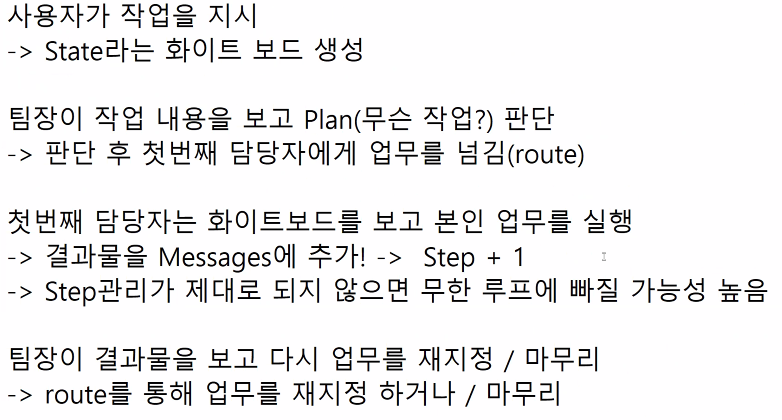

- Worker 에이전트 두 개 만들기 (Weather / Translator)

In [29]:
# 문장에서 '서울' or '광주' 를 찾아내는 함수
def extract_city(user_text: str) -> str :
    """
    사용자 문장에서 '어느 도시의 날씨인지'를 추출하는 함수
    ---------------------------------------------------------------
    📌 어떤 함수인가?
       - 사용자 입력에서 ‘도시 이름’을 간단한 방식(문자열 포함 여부)으로 골라냄
       - Weather Agent가 Tool 호출할 때 필요한 city 파라미터를 만들어 주는 역할

    📌 인자값
       - user_text : 사용자가 입력한 문장 (예: "광주 날씨 알려줘")

    📌 동작 방식
       - if "광주" in user_text : 광주 포함 시 "광주" 반환
       - if "서울" in user_text : 서울 포함 시 "서울" 반환
       - 둘 다 없으면 기본값 "서울" 반환

    📌 왜 기본값이 필요한가?
       - 실제 시스템에서는 NER(개체명 인식) 또는 Geo API 등을 사용하지만,
         이 예제에서는 단순한 문자열 검색만 사용하므로,
         도시가 없는 경우 기본값을 설정하여 그래프가 오류 없이 진행되도록 함
    ---------------------------------------------------------------
    """
    # 문장에 광주가 포함되어 있다면 광주를 반환
    if "광주" in user_text :
      return '광주'

    # 문장에 서울이 포함되어 있다면 서울을 반환
    if "서울" in user_text :
      return '서울'

    # 도시가 언급되지 않으면 서울로 처리
    return '서울'

In [33]:
# --- 2) Worker : Weather agent ---
def weather_agent(state: AgentState) -> AgentState :
    """
    📌 '날씨 조회 전문 Worker 에이전트'

    ✔ 어떤 코드인가?
      - Supervisor가 “날씨 담당 에이전트를 호출하라”라고 결정하면
        실제로 날씨 정보를 생성하는 역할을 수행하는 Worker 노드.
      - 사용자 질문에서 도시를 추출 → Tool 호출 → AIMessage 생성.

    ✔ 어떤 인자가 들어오는가?
      - state : AgentState 구조의 dict
        → 지금까지의 messages, plan, step 등이 모두 들어 있음.

    ✔ 어떤 라이브러리 함수가 쓰였나?
      - route( generator ): generator 에서 조건에 맞는 첫 번째 요소 찾기
      - isinstance(msg, HumanMessage): 메시지 타입 검사
      - extract_city(): 사용자 문장에서 도시명 추출
      - get_weather.invoke(): LangChain Tool 호출 메서드
      - AIMessage(): LangChain 표준 응답 메시지 생성 클래스
    """
    # 1) state['messages'] 중에서 첫번째 사용자 질문(HumanMessage)찾기
    first_human = next(m for m in state['messages'] if isinstance(m, HumanMessage))

    # 2) 사용자 문장에서 도시명 추출 (서울 / 광주)
    city = extract_city(first_human.content)

    # 3) 날씨 도구 호출
    # get_weather는 함수 @Tool 데코레이터로 등록
    # 도구를 불러올 때 invoke({'city' : city})
    weather_text = get_weather.invoke({'city' : city})

    # state 반환
    return {
        'messages' : [AIMessage(content = f"[WETHER_AGENT] {weather_text}")],
        'plan' : state['plan'],     # 기존 플랜 유지
        'step' : state['step'] + 1 , # 반드시 +1을 해줘야 동일한 작업을 반복하지 않는다.
        'route' : ""  # 관리자가 다음 절차에서 어디로 갈지 다시 재지정
    }

In [56]:
# --- 3) Worker : Translator agent ---
def translator_agent(state: AgentState) -> AgentState :
    """
    📌 '영어 번역 전문 Worker 에이전트'

    ✔ 어떤 코드인가?
      - Weather Agent가 출력한 결과(한국어)를 가져와서
        LLM에게 “한 문장으로 자연스럽게 영어로 번역해줘” 요청하는 역할.

    ✔ 어떤 인자가 들어오는가?
      - state : AgentState
        → messages, plan, step 등이 들어 있음.

    ✔ 어떤 함수가 쓰였는가?
      - state["messages"][-1] : 최신 메시지 가져오기
      - llm.invoke() : LangChain ChatModel 직접 호출
      - AIMessage(res.content) : 번역된 텍스트를 AI 응답 메시지로 감싸기
    """

    # 1) 가장 최근 메세지를 번역대상 텍스트로 사용
    last_text = state['messages'][-1].content

    # 2) llm.invoke() : LLM에게 직접 문자열 프롬프트 전달
    # >> ChatModel이 AIMessage(content='...') 형태로 결과 반환
    res = llm.invoke(
        f"[TRANSLATOR_AGENT]\n다음 내용을 영어 한 문장으로 자연스럽게 번역해줘.:\n{last_text}"
    )

    # 3) 번역된 텍스트를 새 AIMessage로 반환
    return {
        'messages' : [AIMessage(content = res.content)],
        'plan' : state['plan'],
        'step' : state['step'] + 1,
        'route' : ""
    }

- LangGraph 기반 Supervisor 노드 구현

In [57]:
# --- 4) Supervisor 노드(조건부 edge 분기) ---
def supervisor(state: AgentState) -> AgentState :
    """
    📌 Supervisor 노드란?
      - 여러 Worker Agent 중, '지금은 누구를 실행할지' if/else로 결정해주는 감독자 노드.
      - 여러 Worker Agent(Weather / Translator)가 있을 때,
        "지금은 어떤 에이전트를 다음으로 실행해야 하는지"를 결정해주는 '감독자' 역할.
      - 직접 일을 하진 않고, 일을 분배하는 컨트롤 타워라고 보면 됨

    📌 인자값
      - state: AgentState 타입의 딕셔너리
        - state["messages"] : 지금까지의 대화 메시지들
        - state["plan"]     : 전체 처리 계획 (weather_only, translate_only 등)
        - state["step"]     : 현재 몇 번째 단계인지(0, 1, 2…)
        - state["route"]    : 다음에 이동할 노드 이름(이 함수에서 결정)

    📌 반환값
      - 똑같이 AgentState 형태의 딕셔너리
        - messages : Supervisor는 실제 답변을 만들지 않으므로 항상 []
        - plan     : 새로 계산되었거나, 유지해야 하는 plan
        - step     : 현재 단계 (증가는 Worker에서 수행)
        - route    : 다음에 실행할 노드 이름 (WEATHER_AGENT / TRANSLATOR_AGENT / FINISH)

    📌 동작 흐름
      1. 아직 아무 Worker도 실행되지 않은 최초 상태(step == 0 & plan 없음)라면,
         → 사용자 첫 질문을 보고 extract_plan()으로 plan을 정함.
      2. plan + step 조합을 보고 다음 route를 결정 (FSM처럼 동작)
         - weather_only:
             step 0 → WEATHER_AGENT
             step 1 → FINISH
         - translate_only:
             step 0 → TRANSLATOR_AGENT
             step 1 → FINISH
         - weather_then_translate:
             step 0 → WEATHER_AGENT
             step 1 → TRANSLATOR_AGENT
             step 2 → FINISH
         - 그 외(plan == "finish" 등) → FINISH
    """
    # --- 1) 최초 호출이면 step과 plan을 꺼내오자
    # .get('step', 0) : 키가 없으면 기본값으로 0을 쓰겠다.
    step = state.get('step', 0)
    plan = state.get('plan', '')

    # 2) plan 계산
    # state['messages] 중에서 HumanMessage 타입인 첫번째 메세지 찾기
    # -> 사용자가 처음에 무엇을 질문했는지 알아보자.
    first_human = next(m for m in state['messages'] if isinstance(m, HumanMessage))

    # 사용자의 자연어 문장을 보고 -> plan에 지정된 문자열로 바꾸는 함수
    # 예 : '서울 날씨 알려주고 영어로 말해줘' -> 'weather_then_translate'
    plan = extract_plan(first_human.content)

    # 3) plan + step 기반 분기점 나눠주기
    # 무슨 에이전트를 불러와서 일을 진행 할 것인가?
    # 날씨만 필요한 경우
    # step 0 : 날씨 에이전트 호출
    # step 1 : 종료
    if plan == 'weather_only' :
        route = 'WEATHER_AGENT' if step == 0 else 'FINISH'

    elif plan == 'translate_only' :
        route = 'TRANSLATOR_AGENT' if step == 0 else 'FINISH'

    elif plan == 'weather_then_translate' :
        if step == 0 :
            route = 'WEATHER_AGENT'
        elif step == 1 :
            route = 'TRANSLATOR_AGENT'
        else :
            route = 'FINISH'

    else :
        # plan이 finish / 예기치 못한 값인 경우
        # -> 바로 종료
        route = "FINISH"

    # Supervisor는 실제 메세지를 생성하지 않는다.
    # 대신 다음에 어디로 갈지와 plan / step 만 셋팅해서 반환
    return {
        "messages" : [],  # 감독자는 답을 생성하지 않기 때문에 빈 리스트로 지정
        'plan' : plan,    # 계산된 plan 유지
        'step' : step,    # 현재 단계 그대로 유지 -> step 관리 (증가는 일꾼들이 일을 마무리하고 나서 증가)
        'route' : route   # 다음에 실행해야 할 노드 이름
    }



- LangGraph StateGraph로 연결 + 조건부 edge 붙이기

In [58]:
# --- 5) 그래프 구성 ---
# 1. AgentState 타입을 상태로 사용하는 그래프 생성
graph_cond = StateGraph(AgentState)

# 2. 그래프에 함수(노드) 등록
# 여기에서 함수이름(노드이름)은 그래프 내부에서 사용할 식별 도구 (이름표)
# route / goto 기능을 이용해서 다음 워커 지정하고 이동을 시키는데 사용

graph_cond.add_node('supervisor', supervisor)
graph_cond.add_node('weather_agent', weather_agent)
graph_cond.add_node('translator_agent', translator_agent)

# 3. 그래프 작업흐름 만들어주기
# 1) 그래프 시작점 -> supervisor
# 항상 supervisor로 가서 어떤 plan으로 갈지 먼저 지정
graph_cond.add_edge(START, 'supervisor')

# 2) weather_agent 작업이 끝나면 다시 supervisor로 돌아오는 구조 만들기
graph_cond.add_edge('weather_agent', 'supervisor')

# 3) translator_agent 작업이 끝나면 다시 supervisor로 돌아오는 구조 만들기
graph_cond.add_edge('translator_agent', 'supervisor')

In [59]:
# 조건부 엣지(흐름) 정의
# - add_conditional_edges('노드이름', 분기함수, 분기 매핑 dict)
# - '관리자' 노드가 끝난 후 state['route']값을 보고 다음 노드를 동적으로 결정하는 구조

graph_cond.add_conditional_edges(
    'supervisor', # 조건 분기. 담당 노드 지정
    lambda s : s['route'], # 상태 s에서 route만 꺼내와서 분기 지점에 사용
    {
        # 만약 route가 'WEATHER_AGENT'라면 -> 'weather_agent' 노드로 이동
        'WEATHER_AGENT' : 'weather_agent',

        # 만약 route가 'TRANSLATOR_AGENT'라면 -> 'translator_agent' 노드로 이동
        'TRANSLATOR_AGENT' : 'translator_agent',

        # 만약 route가 'FINISH'라면 -> END 노드로 이동
        'FINISH' : END
    }
)

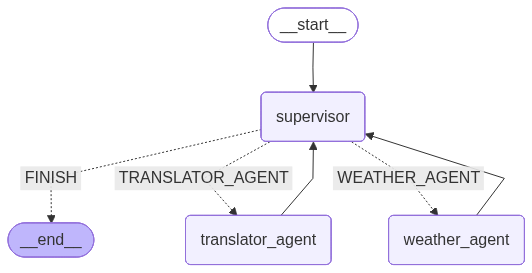

In [60]:
# 그래프 컴파일 -> 실제 실행가능한 그래프로 변환
multi_agent_graph_conditional = graph_cond.compile()
multi_agent_graph_conditional

- 중앙 관제탑 방식

In [61]:
# --- 6) 실행용 헬퍼 & 예시 ---

def print_stream_conditional(stream):
    """
    📌 새 메시지가 추가되었을 때만 마지막 메시지를 출력하는 헬퍼 함수
        - LangGraph의 .stream() 은 '상태(State)'를 여러 번 연속으로 보내는데,
          이 중에서 "새로운 메시지가 추가된 시점"만 골라서 출력하는 헬퍼 함수.
        - 즉, Worker 또는 Supervisor가 메시지를 만들 때만 출력하도록 하는 필터 역할.

    📌 들어오는 인자값 (stream)
        - multi_agent_graph_conditional.stream(...) 의 결과.
        - 제너레이터(generator) 형태이며,
          한 번 실행할 때마다 state(dict)를 하나씩 내보낸다.

        예: 다음처럼 생긴 state가 반복적으로 들어옴
            {
                "messages": [...],
                "plan": "...",
                "step": 1,
                "route": "WEATHER_AGENT"
            }

    📌 동작 방식 요약
        1. 이전 메시지 개수를 last_len 에 저장한다.
        2. stream으로부터 새로운 state가 들어올 때마다 messages 길이를 확인한다.
        3. 메시지가 새로 추가된 경우에만 마지막 메시지를 출력한다.
           (Supervisor 노드처럼 messages를 추가하지 않는 노드는 건너뜀)
    """

    last_len = -1  # 직전 메시지 개수를 저장하기 위한 변수 (처음엔 -1)

    for s in stream:     # graph.stream(...) 이 보내주는 state들을 순차적으로 받음
        msgs = s["messages"]  # 현재 state의 메시지 리스트

        # 메시지가 늘지 않았다면 → 이 단계에서는 실제 Worker가 메시지를 안 만든 것
        if len(msgs) == last_len:
            continue  # 출력 스킵하고 다음 state로 넘어감

        # 메시지가 새로 추가된 경우 → 마지막 메시지를 출력해야 함
        last_len = len(msgs)
        msgs[-1].pretty_print()   # 가장 마지막 메시지를 출력

In [62]:
# 날씨 질문만 있는 경우
print_stream_conditional(
    multi_agent_graph_conditional.stream(
        {'messages' : [('user', '서울 날씨 알려줘.')]},
        stream_mode = 'values'
    )
)

================================ Human Message =================================

서울 날씨 알려줘.
================================== Ai Message ==================================

[WETHER_AGENT] 서울은 오늘 흐리고 후덥지근 합니다.


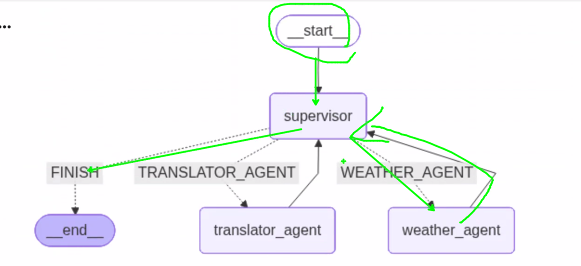

In [63]:
# 번역 질문만 있는 경우
print_stream_conditional(
    multi_agent_graph_conditional.stream(
        {'messages' : [('user', '다음 문장을 영어문장 으로 바꿔줘. : 집 가고 싶다.')]},
        stream_mode = 'values'
    )
)

================================ Human Message =================================

다음 문장을 영어문장 으로 바꿔줘. : 집 가고 싶다.
================================== Ai Message ==================================

I want to go home.


In [66]:
# 날씨 + 번역 질문 있는 경우
print_stream_conditional(
    multi_agent_graph_conditional.stream(
        {'messages' : [('user', '서울 날씨에 대해서 알려주고, 영어로 번역해줘')]},
        stream_mode = 'values'
    )
)

================================ Human Message =================================

서울 날씨에 대해서 알려주고, 영어로 번역해줘
================================== Ai Message ==================================

[WETHER_AGENT] 서울은 오늘 흐리고 후덥지근 합니다.
================================== Ai Message ==================================

Seoul is cloudy and muggy today.




### (2) Command 기반 Handoff
> LangGraph에서는 `Command(goto="다음_노드", graph=Command.PARENT, update=...)` 형태로 표현할 수 있음
> - `goto` : 다음에 실행할 노드(또는 에이전트 이름)
> - `graph=Command.PARENT` : “부모 그래프로 돌아가서 그 안에서 이동”
> - `update` : 상태 업데이트 (예: 새 메시지)

In [67]:
# 필요한 라이브러리 불러오기
from langgraph.types import Command
# Command : LangGraph가 가진 특별한 제어 명령
# 노드 함수가 Command 를 반환하면 그래프 엔진은 Command 안의 지시에 따라 노드 / 그래프 / 상태 업데이트 진행

# 주요인자 (매개변수)
# - goto : 다음에 실행 할 노드 이름 / END
# - graph : 어떤 그래프로 이동 할 것인지
# - update : 상태에 병합할 dict

- 상태 클래스 정의

In [68]:
# --- 1) 상태 클래스 정의 ---
# Command 기반 버전에서도 상태구조는 거의 동일하게 사용
class AgentStateCmd(TypedDict) :
    """
    📌 클래스
        - Multi-Agent 그래프에서 'State'의 구조를 정의하는 데이터 틀.
        - 그래프의 모든 노드(worker, supervisor)는 이 형태의 dict을 주고받음

    📌 사용된 기능
        - TypedDict : Python에서 "dict 형태지만 key 타입을 명확히 정의"하는 방식
        - Annotated + add_messages :
            LangGraph가 messages 리스트에 새 메시지를 자동으로 이어붙이도록 설정

    📌 구성 요소
        messages : 지금까지의 모든 메시지 기록
        plan     : Supervisor가 계산한 전체 작업 계획(plan)
        step     : 현재 몇 번째 단계인지 나타내는 숫자
    """
    messages: Annotated[Sequence[BaseMessage], add_messages]
    plan: str
    step: int

- 워커 생성 (weather & Translator)

In [74]:
# --- Worker : Weather agent (Command ver) ---
def weather_agent_cmd(state: AgentStateCmd) -> AgentStateCmd :
    """
    📌 '날씨 조회 전문 Worker 에이전트'

    ✔ 어떤 코드인가?
      - Supervisor가 “날씨 담당 에이전트를 호출하라”라고 결정하면
        실제로 날씨 정보를 생성하는 역할을 수행하는 Worker 노드.
      - 사용자 질문에서 도시를 추출 → Tool 호출 → AIMessage 생성.

    ✔ 어떤 인자가 들어오는가?
      - state : AgentStateCmd 구조의 dict
        → 예 : {
          'messages' : [...],
          'plan' : 'weather_then_translate',
          'step' : 0
        }

    ✔ 어떤 라이브러리 함수가 쓰였나?
      - isinstance(msg, HumanMessage): 메시지 타입 검사
      - extract_city(): 사용자 문장에서 도시명 추출
      - get_weather.invoke(): LangChain Tool 호출 메서드
      - AIMessage(): LangChain 표준 응답 메시지 생성 클래스
    """
    # 1) state['messages'] 중에서 첫번째 사용자 질문(HumanMessage)찾기 - 조건부 엣지와 동일
    first_human = next(m for m in state['messages'] if isinstance(m, HumanMessage))

    # 2) 사용자 문장에서 도시명 추출 (서울 / 광주) - 조건부 엣지와 동일
    city = extract_city(first_human.content)

    # 3) 날씨 도구 호출 - 조건부 엣지와 동일
    # get_weather는 함수 @Tool 데코레이터로 등록
    # 도구를 불러올 때 invoke({'city' : city})
    weather_text = get_weather.invoke({'city' : city})

    # state 반환
    return {
        'messages' : [AIMessage(content = f"[WETHER_AGENT] {weather_text}")],
        'plan' : state.get('plan', ''),     # 기존 플랜 유지
        'step' : state.get('step', 0) + 1 , # 반드시 +1을 해줘야 동일한 작업을 반복하지 않는다.
    }

In [76]:
# --- Worker : Translator agent (Command ver) ---
def translator_agent_cmd(state: AgentStateCmd) -> AgentStateCmd :
    """
    📌 '영어 번역 전문 Worker 에이전트'

    ✔ 어떤 코드인가?
      - Weather Agent가 출력한 결과(한국어)를 가져와서
        LLM에게 “한 문장으로 자연스럽게 영어로 번역해줘” 요청하는 역할.

    ✔ 어떤 인자가 들어오는가?
      - state : AgentState
        → messages, plan, step 등이 들어 있음.

    ✔ 어떤 함수가 쓰였는가?
      - state["messages"][-1] : 최신 메시지 가져오기
      - llm.invoke() : LangChain ChatModel 직접 호출
      - AIMessage(res.content) : 번역된 텍스트를 AI 응답 메시지로 감싸기
    """

    # 1) 가장 최근 메세지를 번역대상 텍스트로 사용
    last_text = state['messages'][-1].content

    # 2) llm.invoke() : LLM에게 직접 문자열 프롬프트 전달
    # >> ChatModel이 AIMessage(content='...') 형태로 결과 반환
    res = llm.invoke(
        f"[TRANSLATOR_AGENT]\n다음 내용을 영어 한 문장으로 자연스럽게 번역해줘.:\n{last_text}"
    )

    # 3) 번역된 텍스트를 새 AIMessage로 반환
    return {
        'messages' : [AIMessage(content = res.content)],
        'plan' : state.get('plan', ''),
        'step' : state.get('step', 0) + 1,
    }

- Supervisor 구현 (Command로 직접 handoff)

In [73]:
# --- Supervisor 노드(Command 로 직접 핸드오프) ---
def supervisor_cmd(state: AgentStateCmd) -> Command:
    """
    📌 어떤 함수인가?
        - 여러 Worker 중에서 "다음에 누구를 실행할지"를 결정하는 감독자(Supervisor) 노드.
        - 단, 이전(조건부 edge 버전)과 달리,
          이번에는 'State(dict)'가 아니라 'Command 객체'를 반환해서
          그래프에게 직접 "다음엔 여기로 가!" 라고 명령하는 방식.

    📌 인자값
        - state : AgentStateCmd 타입의 dict
          - state["messages"] : 전체 대화 메시지 (Human/AI)
          - state["plan"]     : 전체 계획 (weather_only, translate_only 등)
          - state["step"]     : 현재까지 수행된 단계(0, 1, 2…)

    📌 반환값
        - Command 객체
          - goto   : 다음에 실행할 노드 이름 또는 END
          - update : 상태에 반영할 값들(plan, step 등)
    """
    # --- 1) 최초 호출이면 step과 plan을 꺼내오자 - 변경없음
    # .get('step', 0) : 키가 없으면 기본값으로 0을 쓰겠다.
    step = state.get('step', 0)
    plan = state.get('plan', '')

    # 2) plan 계산
    # state['messages] 중에서 HumanMessage 타입인 첫번째 메세지 찾기
    # -> 사용자가 처음에 무엇을 질문했는지 알아보자.
    # 최초 호출이면 plan을 알아봐야 한다.
    if step == 0 and not plan :
        first_human = next(m for m in state['messages'] if isinstance(m, HumanMessage))
        # 사용자의 자연어 문장을 보고 -> plan에 지정된 문자열로 바꾸는 함수
        # 예 : '서울 날씨 알려주고 영어로 말해줘' -> 'weather_then_translate'
        plan = extract_plan(first_human.content)

    # 3) plan + step 기반 분기점 나눠주기
    # 무슨 에이전트를 불러와서 일을 진행 할 것인가?
    # 날씨만 필요한 경우
    # step 0 : 날씨 에이전트 호출
    # step 1 : 종료
    if plan == 'weather_only' :
        if step == 0 :
            goto = 'weather_agent_cmd'
        else :
            goto = END

    elif plan == 'translate_only' :
        if step == 0 :
            goto = 'translator_agent_cmd'
        else :
            goto = END

    elif plan == 'weather_then_translate' :
        if step == 0 :
              goto = 'weather_agent_cmd'
        elif step == 1 :
              goto = 'translator_agent_cmd'
        else :
              goto = END

    else :
        # plan이 finish / 예기치 못한 값인 경우
        # -> 바로 종료
        goto = END

    # Supervisor는 실제 메세지를 생성하지 않는다.
    # 대신 다음에 어디로 갈지와 plan / step 만 셋팅해서 반환
    return Command(
        goto = goto,
        update = {'plan' : plan, 'step' : step}
    )


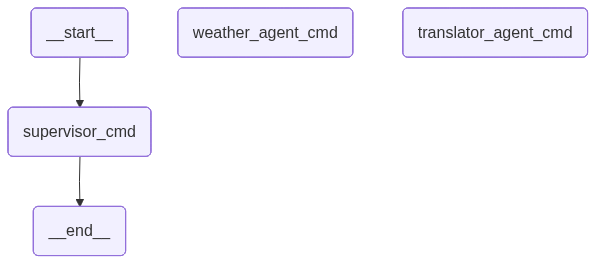

In [77]:
# --- 5) 그래프 구성 (Command ver) ---

graph_cmd = StateGraph(AgentStateCmd)

# 함수등록
graph_cmd.add_node('supervisor_cmd', supervisor_cmd)
graph_cmd.add_node('weather_agent_cmd', weather_agent_cmd)
graph_cmd.add_node('translator_agent_cmd', translator_agent_cmd)

# 흐름도 정의
# 1) 그래프 시작점 > supervisor
graph_cmd.add_edge(START, 'supervisor_cmd')

# 2) 날씨 제공 기능이 끝나면 supervisor_cmd로 돌아오는 흐름
graph_cmd.add_edge('weather_agent_cmd', 'supervisor_cmd')

# 3) 번역 제공 기능이 끝나면 supervisor_cmd로 돌아오는 흐름
graph_cmd.add_edge('translator_agent_cmd', 'supervisor_cmd')

# 4) supervisor에서 END로 가는 흐름도 만들어 주자
graph_cmd.add_edge('supervisor_cmd', END)

# 그래프 컴파일
multi_agent_graph_command = graph_cmd.compile()
multi_agent_graph_command

- 바통 터치 방식, goto가 다음 순서를 명시적으로 선택한다.
- 즉각적인 반응에 대해

In [78]:
# --- 6) 실행 헬퍼 & 예시 ---

def print_stream_command(stream):
    """
    📌 이 함수는 뭐하는 함수인가?
        - Command 기반 Multi-Agent 그래프를 실행하면
          .stream()이 여러 개의 'state(dict)'를 순서대로 보내준다.
        - 그 state 안에 messages 리스트가 있는데,
          Worker Agent가 실제로 새 메시지를 만들었을 때만 출력하고 싶을 때 사용하는 헬퍼 함수.

        → 즉, "메시지가 새로 생성된 순간만 예쁘게 출력해주는 필터 함수".

    📌 들어오는 인자 (stream)
        - multi_agent_graph_command.stream(...) 이 반환한 제너레이터.
        - 이 제너레이터는 한 단계 실행할 때마다 state(dict)를 계속 보내줌.

        예: state 구조 예시
        {
            "messages": [...],
            "plan": "weather_then_translate",
            "step": 1
        }

    📌 동작 원리
        1. last_len 변수로 이전 메시지 개수를 저장한다.
        2. 새로운 state가 들어올 때마다 messages 길이를 비교한다.
        3. 메시지가 증가했다면 → Worker가 새 메시지를 만든 것이므로 출력.
        4. Supervisor처럼 메시지를 만들지 않는 노드 단계는 자동으로 건너뜀.
    """

    last_len = -1  # 이전 messages 개수 저장용 (초기값 -1)

    # stream 으로부터 state(dict)들이 순서대로 들어옴
    for s in stream:
        msgs = s["messages"]  # 현재 상태의 메시지 기록 리스트

        # 메시지 개수 변화 없으면 "새 메시지 없음" → 넘어감
        if len(msgs) == last_len:
            continue

        # 새 메시지가 생겼으므로 길이를 갱신하고 출력
        last_len = len(msgs)
        msgs[-1].pretty_print()  # LangChain 메시지 객체를 출력


In [79]:
# 테스트 진행
# 1) 날씨 질문만 있는 경우
print_stream_command(
    multi_agent_graph_command.stream(
        {'messages' : [('user', '서울 날씨 알려줘.')]},
        stream_mode = 'values'
    )
)

================================ Human Message =================================

서울 날씨 알려줘.
================================== Ai Message ==================================

[WETHER_AGENT] 서울은 오늘 흐리고 후덥지근 합니다.


In [80]:
# 2) 날씨+번역 질문 있는 경우
print_stream_command(
    multi_agent_graph_command.stream(
        {'messages' : [('user', '서울 날씨 알려주고 영어로 번역해줘')]},
        stream_mode = 'values'
    )
)

================================ Human Message =================================

서울 날씨 알려주고 영어로 번역해줘
================================== Ai Message ==================================

[WETHER_AGENT] 서울은 오늘 흐리고 후덥지근 합니다.
================================== Ai Message ==================================

Seoul is cloudy and muggy today.


In [82]:
# 3) 번역 질문만 있는 경우
print_stream_command(
    multi_agent_graph_command.stream(
        {'messages' : [('user', '다음 문장을 영어 한 문장으로 바꿔줘 : 수업 끝!')]},
        stream_mode = 'values'
    )
)

================================ Human Message =================================

다음 문장을 영어 한 문장으로 바꿔줘 : 수업 끝!
================================== Ai Message ==================================

Class is over!
